### Hotel Booking Cancellation Prediction

#### Problem Statement
“In the hospitality industry, booking cancellations are a major issue that leads to revenue loss and poor resource planning.

 So, I built a predictive model that helps identify customers who are likely to cancel their bookings in advance.”

#### Import libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

### Load Dataset

In [2]:
df = pd.read_excel(r"C:\infotact_intership\Excel Data- Hospitality.xlsx")

In [3]:
# Basic inforamation
df.head()

,booking_id,customer_id,booking_date,check_in_date,check_out_date,hotel_city,customer_type,room_type,lead_time,stay_duration,avg_daily_rate,total_price,booking_channel,is_canceled,group
0,1001,C1127,2024-08-15,2024-09-06,2024-09-09,Bangalore,Returning,Suite,22,3,5867,17601,Agent,0,A
1,1002,C1460,2024-03-06,2024-03-24,2024-03-26,Hyderabad,Returning,Standard,18,2,5895,11790,Agent,0,B
2,1003,C0861,2024-11-30,2024-12-14,2024-12-15,Mumbai,Returning,Standard,14,1,3313,3313,Agent,0,A
3,1004,C1295,2024-09-18,2024-09-28,2024-10-01,Chennai,New,Suite,10,3,3345,10035,Agent,0,A
4,1005,C1131,2024-10-21,2024-12-06,2024-12-10,Mumbai,Returning,Suite,46,4,3664,14656,Agent,1,B


In [4]:
# Dataset shape
df.shape

(2000, 15)

In [5]:
# check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   booking_id       2000 non-null   int64         
 1   customer_id      2000 non-null   object        
 2   booking_date     2000 non-null   datetime64[ns]
 3   check_in_date    2000 non-null   datetime64[ns]
 4   check_out_date   2000 non-null   datetime64[ns]
 5   hotel_city       2000 non-null   object        
 6   customer_type    2000 non-null   object        
 7   room_type        2000 non-null   object        
 8   lead_time        2000 non-null   int64         
 9   stay_duration    2000 non-null   int64         
 10  avg_daily_rate   2000 non-null   int64         
 11  total_price      2000 non-null   int64         
 12  booking_channel  2000 non-null   object        
 13  is_canceled      2000 non-null   int64         
 14  group            2000 non-null   object 

In [6]:
df.describe()

,booking_id,booking_date,check_in_date,check_out_date,lead_time,stay_duration,avg_daily_rate,total_price,is_canceled
count,2000.000000,2000,2000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2000.500000,2024-06-29 10:43:40.800000,2024-07-30 04:49:26.400000,2024-08-02 05:13:12,30.754000,3.016500,5670.635000,17158.331500,0.559500
min,1001.000000,2024-01-01 00:00:00,2024-01-06 00:00:00,2024-01-09 00:00:00,1.000000,1.000000,2512.000000,2528.000000,0.000000
25%,1500.750000,2024-04-02 00:00:00,2024-05-04 00:00:00,2024-05-08 00:00:00,16.000000,2.000000,4043.750000,8364.000000,0.000000
50%,2000.500000,2024-06-23 00:00:00,2024-07-24 00:00:00,2024-07-28 00:00:00,30.000000,3.000000,5681.500000,15521.000000,1.000000
75%,2500.250000,2024-09-28 06:00:00,2024-10-30 06:00:00,2024-11-03 00:00:00,46.000000,4.000000,7256.250000,23755.500000,1.000000
max,3000.000000,2024-12-30 00:00:00,2025-02-25 00:00:00,2025-02-27 00:00:00,59.000000,5.000000,8999.000000,44995.000000,1.000000
std,577.494589,NaN,NaN,NaN,17.261068,1.405068,1849.354885,10100.439139,0.496571


In [7]:
# check of missing values 
print("Missing Values")
print(df.isnull().sum())

Missing Values
booking_id         0
customer_id        0
booking_date       0
check_in_date      0
check_out_date     0
hotel_city         0
customer_type      0
room_type          0
lead_time          0
stay_duration      0
avg_daily_rate     0
total_price        0
booking_channel    0
is_canceled        0
group              0
dtype: int64


In [114]:
# Churn = Booking Cancelled (1), Not Cancelled (0)
df['is_canceled'].value_counts()

is_canceled
1    1119
0     881
Name: count, dtype: int64

In [115]:
# Churn Metrics
    # 1 = Booking Cancelled
    # 0 = Booking Not Cancelled”
total_customers = len(df)
churned = df['is_canceled'].sum()
retained = total_customers - churned

churn_rate = churned / total_customers
retention_rate = retained / total_customers

print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned}")
print(f"Retention Rate: {retention_rate:.2f}")
print(f"Churn Rate: {churn_rate:.2f}")

Total Customers: 2000
Churned Customers: 1119
Retention Rate: 0.44
Churn Rate: 0.56


### EDA (Exploratory Data Analysis)

In [8]:
df['days_between_booking_checking'] = (df['check_in_date'] - df['booking_date']).dt.days

In [118]:
df['days_between_booking_checking'].head(2)

0    22
1    18
Name: days_between_booking_checking, dtype: int64

##### Cancellation Analysis

C:\Users\Harsh\AppData\Local\Temp\ipykernel_15712\2198200890.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


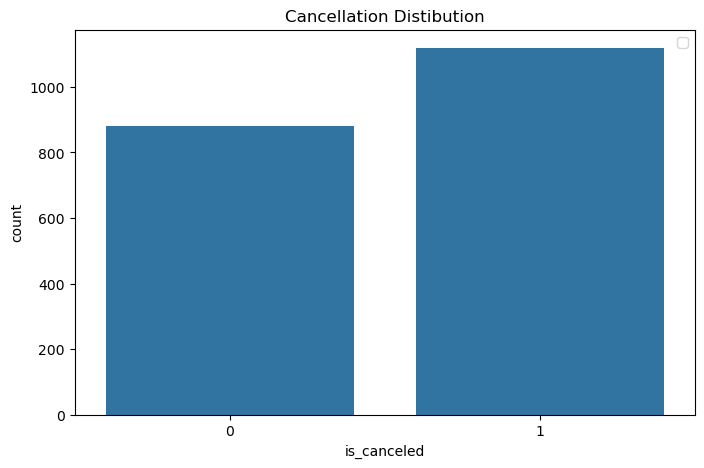

In [10]:
# CHURN ANALYSIS
plt.figure(figsize=(8,5))
sns.countplot (x = 'is_canceled', data=df)
plt.title('Cancellation Distibution')
plt.legend()
plt.show()

##### Correlation Matrix

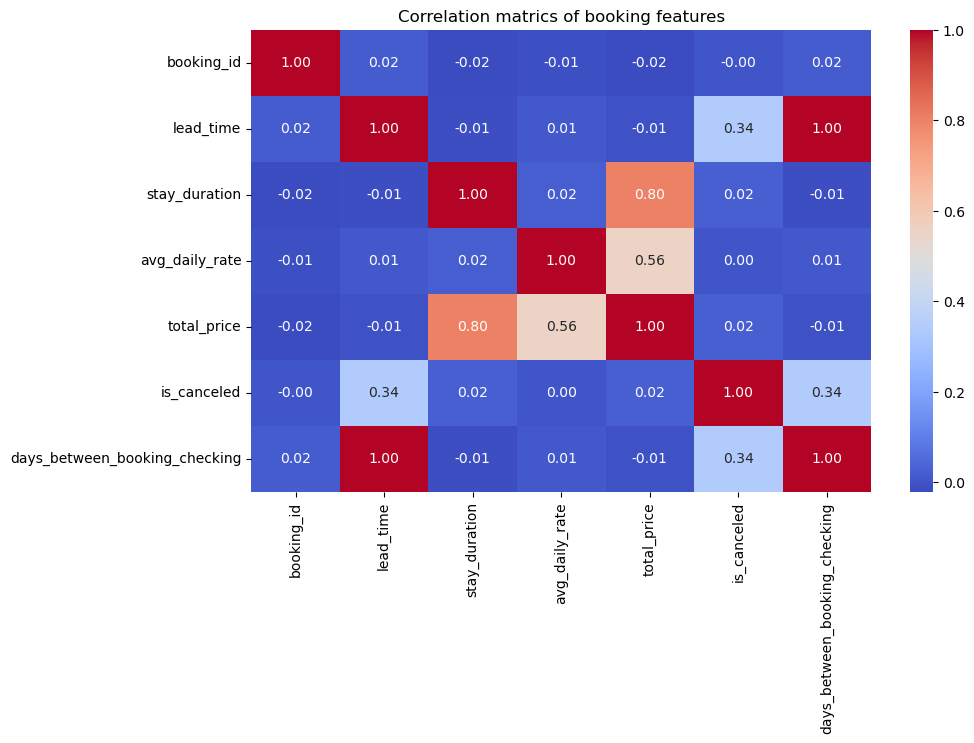

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation matrics of booking features")
plt.show()

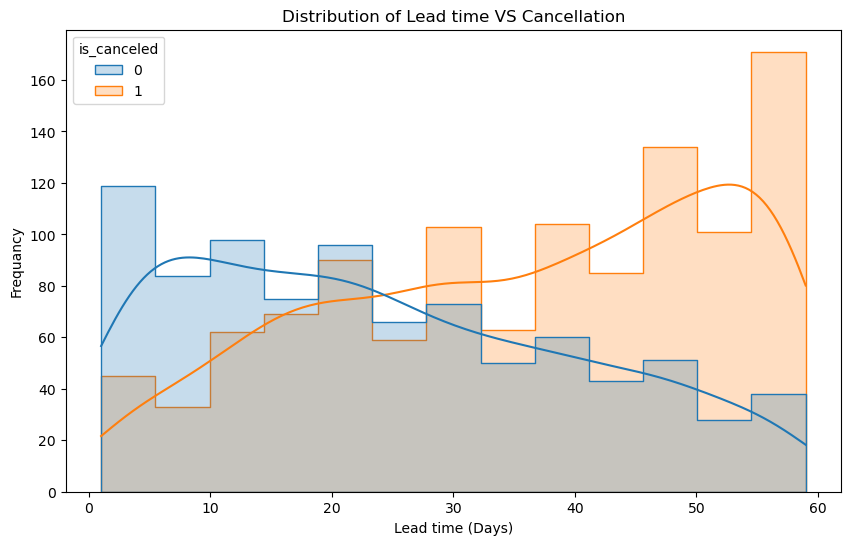

In [16]:
# Distibution of lead Time vs Cancellation 
plt.figure(figsize=(10,6))
sns.histplot(data=df, x = 'lead_time',hue='is_canceled',kde=True, element='step')
plt.title("Distribution of Lead time VS Cancellation")
plt.xlabel('Lead time (Days)')
plt.ylabel('Frequancy')
plt.show()

C:\Users\Harsh\AppData\Local\Temp\ipykernel_15712\1072531666.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x = 'customer_type', y = 'is_canceled',palette='viridis')


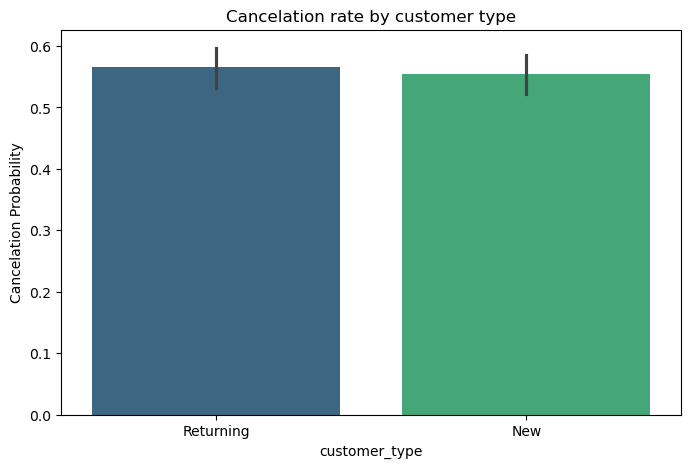

In [34]:
# Cancellation rate by Costomer Type 
plt.figure(figsize=(8,5))
sns.barplot(data=df, x = 'customer_type', y = 'is_canceled',palette='viridis')
plt.title('Cancelation rate by customer type')
plt.ylabel('Cancelation Probability')
plt.show()

### Feature Engineering

In [89]:
# Model Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve

In [40]:
#Encode Categorical Data
le = LabelEncoder() 

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [47]:
# Check the datatype
print(df.info())
print('=' * 50)
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   booking_id                     2000 non-null   int64         
 1   customer_id                    2000 non-null   int32         
 2   booking_date                   2000 non-null   datetime64[ns]
 3   check_in_date                  2000 non-null   datetime64[ns]
 4   check_out_date                 2000 non-null   datetime64[ns]
 5   hotel_city                     2000 non-null   int32         
 6   customer_type                  2000 non-null   int32         
 7   room_type                      2000 non-null   int32         
 8   lead_time                      2000 non-null   int64         
 9   stay_duration                  2000 non-null   int64         
 10  avg_daily_rate                 2000 non-null   int64         
 11  total_price      

In [78]:
#Feature Selection
X = df.drop(['is_canceled','booking_date','check_in_date','check_out_date'],axis=1)
y = df['is_canceled']

#### Train-Test Split

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
X_train.head(2)

,booking_id,customer_id,hotel_city,customer_type,room_type,lead_time,stay_duration,avg_daily_rate,total_price,booking_channel,group,days_between_booking_checking
968,1969,168,4,1,1,36,3,5954,17862,0,0,36
240,1241,141,4,0,2,23,5,6401,32005,1,1,23


In [81]:
y_trin.head(2)

968    1
240    0
Name: is_canceled, dtype: int64

In [86]:
print("X_train Data shape",X_train.shape)
print('X_Test Data Shape',X_test.shape)
print('y_Train Data Shape', y_train.shape)
print('y_Test Data shape', y_test.shape)

X_train Data shape (1600, 12)
X_Test Data Shape (400, 12)
y_Train Data Shape (1600,)
y_Test Data shape (400,)


In [83]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### ML Models



In [112]:
# Used for classification problems use LogisticRegression
# Predicts probability (0 or 1)

lr = LogisticRegression(max_iter=1000, solver='liblinear')

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

#### Decision Tree

In [99]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

### Evaluation

In [129]:
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression:
Accuracy: 0.655
Precision: 0.6556016597510373
Recall: 0.7417840375586855
ROC-AUC: 0.7041249278200395


In [130]:
print("Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Decision Tree:
Accuracy: 0.63
Precision: 0.6294820717131474
Recall: 0.7417840375586855
ROC-AUC: 0.634731741608295


### Confusion Matrix

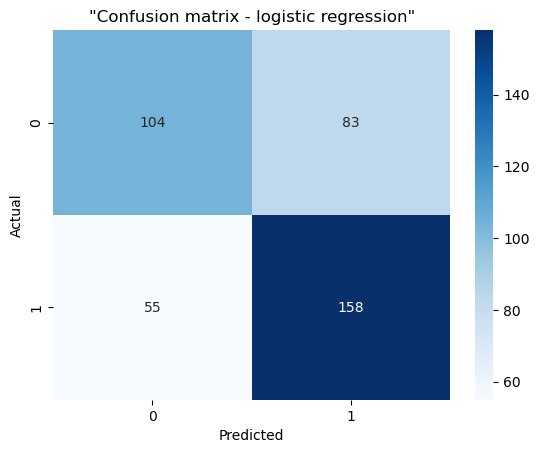

In [104]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('"Confusion matrix - logistic regression"')
plt.xlabel("Predicted")
plt.ylabel('Actual')
plt.show()

#### ROC Curve

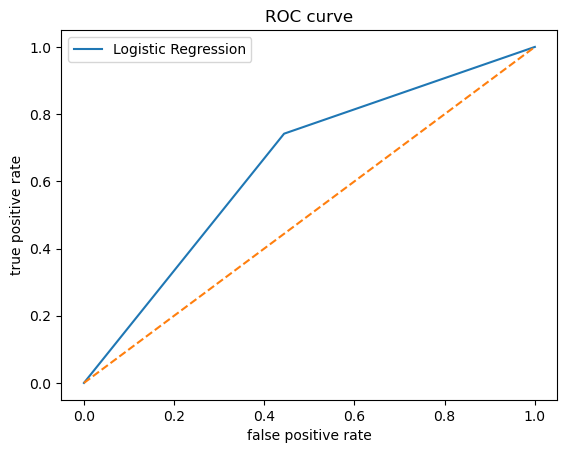

In [106]:
fpr,tpr, _ = roc_curve(y_test, y_pred_lr)

plt.plot(fpr, tpr, label ='Logistic Regression')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC curve')
plt.legend()
plt.show()

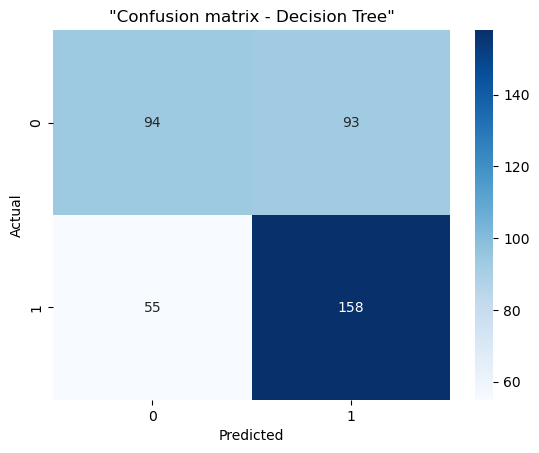

In [111]:
ct = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('"Confusion matrix - Decision Tree"')
plt.xlabel("Predicted")
plt.ylabel('Actual')
plt.show()

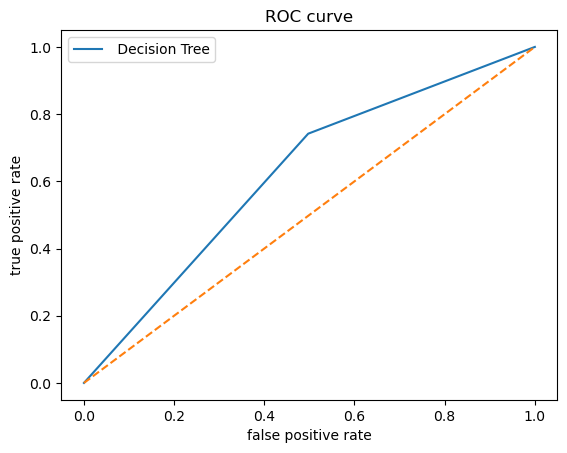

In [110]:
fpr,tpr, _ = roc_curve(y_test, y_pred_dt)

plt.plot(fpr, tpr, label =' Decision Tree')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC curve')
plt.legend()
plt.show()

#### Pipeline

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=500))
])

pipeline.fit(X_train, y_train)

y_pred_pipe = pipeline.predict(X_test)

print("Pipeline Accuracy:", accuracy_score(y_test, y_pred_pipe))

Pipeline Accuracy: 0.645


### Business Conclusion

This project successfully predicts hotel booking cancellations using machine learning. The model helps identify customers who are likely to cancel in advance, allowing hotels to take proactive actions.

By using these insights, businesses can reduce cancellation rates, improve customer retention, optimize pricing strategies, and increase overall revenue.